
# Laboratorio 4 – Árboles de Decisión  
## Pasaporte: puntos 1 al 10

**Curso:** CC3074 – Minería de Datos  
**Caso:** SmartStay Advisors  
**Alumno:** Ian Cumes 23236 Javier Valladares 23045 Javier Cifuentes 23079

Se encuentran los incisos **1 al 10** del laboratorio. De acuerdo con las instrucciones del curso, en esta fase se debe: cargar el dataset, hacer un análisis exploratorio extenso, incluir un análisis de grupos, dividir el set en entrenamiento y prueba, construir árboles de regresión, compararlos con regresión lineal, crear una nueva variable categórica de precios y entrenar un árbol de clasificación sin incluir el precio como predictor. 

> **Nota metodológica:** los puntos 11 al 15 (eficiencia formal del clasificador, matriz de confusión, validación cruzada y random forest) se dejaron fuera de este avance porque pertenecen a la entrega final.


> **Versión revisada del pasaporte (incisos 1 al 10).**  
> Se agregan trazas de preprocesamiento, descripción de variables, justificación de decisiones de clustering, interpretación de PCA, comparación más rica de árboles con cambio de variables, y gráficas adicionales para árboles y regresión lineal.



## 0. Librerías y configuración

Se trabaja en Python porque el laboratorio permite entregar `.ipynb` y además el mismo enunciado sugiere usar `pyreadr` para leer `listings.RData`. 


In [9]:

try:
    import pyreadr
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyreadr", "-q"])
    import pyreadr

import warnings
warnings.filterwarnings("ignore")

import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def parse_money(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace("$","").replace(",","")
    try:
        return float(s)
    except:
        return np.nan

def parse_pct(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace("%","")
    if s == "" or s.lower() == "nan":
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

def parse_numeric(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(",","")
    if s == "" or s.lower() == "nan":
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

def count_list_like(series):
    s = series.fillna("").astype(str)
    quoted = s.str.count(r'"')
    counts = (quoted // 2).astype(float)
    fallback = s.str.count(",") + 1
    counts = counts.where(s.str.len() > 0, np.nan)
    counts = counts.where(counts > 0, fallback.astype(float))
    return counts


## 1. Carga del conjunto de datos

In [10]:

rdata_path = "listings.RData"
result = pyreadr.read_r(rdata_path)
df_raw = list(result.values())[0].copy()

print("Filas originales:", df_raw.shape[0])
print("Columnas originales:", df_raw.shape[1])
df_raw.head(3)


Filas originales: 171748
Columnas originales: 80


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,https://www.airbnb.com/users/show/8028,Sylvia,2009-02-16,"Austin, TX",I am a licensed Real Estate Broker and owner o...,within a few hours,100%,90%,t,https://a0.muscache.com/im/users/8028/profile_...,https://a0.muscache.com/im/users/8028/profile_...,East Downtown,1,2,"['email', 'phone']",t,t,Neighborhood highlights,78702,NaN,30.26057,-97.73441,Entire guesthouse,Entire home/apt,3,1.0,1 bath,1,2,"[""Iron"", ""Private entrance"", ""Hot water"", ""Dis...",$97.00,2,90,2,4,90,90,2.1,90.0,NaN,t,13,35,65,328,2025-09-17,708,25,1,81,33,150,14550,2009-03-19,2025-09-02,4.85,4.88,4.86,4.90,4.82,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,https://www.airbnb.com/users/show/14156,Amy,2009-04-20,"Austin, TX","We are a family of four (with teenagers, all o...",within an hour,100%,96%,t,https://a0.muscache.com/im/users/14156/profile...,https://a0.muscache.com/im/users/14156/profile...,Zilker,1,2,"['email', 'phone']",t,t,Neighborhood highlights,78704,NaN,30.26034,-97.76487,Entire guesthouse,Entire home/apt,2,1.0,1 bath,1,2,"[""Private patio or balcony"", ""Stove"", ""Cleanin...",$160.00,3,365,3,3,1125,1125,3.0,1125.0,NaN,t,12,30,50,316,2025-09-17,339,14,1,61,20,84,13440,2011-09-06,2025-08-20,4.97,4.97,4.96,4.99,4.98,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,https://www.airbnb.com/users/show/25298,Karen,2009-07-11,"Austin, TX",I handle the reservations at the studio on the...,within a day,100%,60%,f,https://a0.muscache.com/im/users/25298/profile...,https://a0.muscache.com/im/users/25298/profile...,East Riverside,1,1,"['email', 'phone']",t,f,,78741,NaN,30.23466,-97.73682,Entire guest suite,Entire home/apt,2,1.0,1 bath,1,1,"[""Wifi"", ""Smoke alarm"", ""Shampoo"", ""Heating"", ...",$38.00,4,90,3,14,90,90,6.0,90.0,NaN,t,29,59,88,88,2025-09-17,54,1,0,88,2,8,304,2010-02-19,2025-05-05,4.57,4.55,4.6


### Comentario inicial

El archivo contiene **171.748 filas** y **80 columnas**. Estamos frente a un dataset suficientemente grande como para justificar limpieza. segmentación y comparación de modelos.

La variable respuesta del laboratorio es el **precio por noche**. pero en el dataset original aparece como texto con símbolo de dólar. Por eso la primera parte del preprocesamiento consiste en convertir esa columna a formato numérico y revisar valores faltantes y extremos.


## 2. Análisis exploratorio extenso y preprocesamiento

In [11]:

df = df_raw.copy()

# Conversión de fechas
for c in ["last_scraped","host_since","calendar_last_scraped","first_review","last_review"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

# Conversión de variables numéricas que venían como texto
df["price_num"] = df["price"].map(parse_money)
df["host_response_rate_num"] = df["host_response_rate"].map(parse_pct)
df["host_acceptance_rate_num"] = df["host_acceptance_rate"].map(parse_pct)

for c in ["beds","bedrooms","host_listings_count","host_total_listings_count",
          "minimum_minimum_nights","maximum_minimum_nights","minimum_maximum_nights",
          "maximum_maximum_nights","estimated_revenue_l365d"]:
    df[c] = df[c].map(parse_numeric)

# Variables derivadas útiles
df["bathrooms_num"] = df["bathrooms"].where(
    df["bathrooms"].notna(),
    df["bathrooms_text"].fillna("").astype(str).str.extract(r"(\d+(\.\d+)?)")[0].astype(float)
)

df["amenities_count"] = count_list_like(df["amenities"])
df["host_verifications_count"] = count_list_like(df["host_verifications"])
df["description_length"] = df["description"].fillna("").astype(str).str.len()
df["host_about_length"] = df["host_about"].fillna("").astype(str).str.len()
df["neighborhood_overview_length"] = df["neighborhood_overview"].fillna("").astype(str).str.len()
df["name_length"] = df["name"].fillna("").astype(str).str.len()

ref_date = df["last_scraped"].max()
df["host_tenure_days"] = (ref_date - df["host_since"]).dt.days
df["days_since_first_review"] = (ref_date - df["first_review"]).dt.days
df["days_since_last_review"] = (ref_date - df["last_review"]).dt.days

# Estandarizar variables booleanas tipo t/f
for c in ["host_is_superhost","host_has_profile_pic","host_identity_verified","has_availability","instant_bookable"]:
    df[c] = df[c].replace({"t":"Sí","f":"No","":"Desconocido"}).fillna("Desconocido")

missing_summary = (
    df.isna().mean()
      .sort_values(ascending=False)
      .rename("missing_pct")
      .to_frame()
)
missing_summary.head(15)


,missing_pct
calendar_updated,1.000000
estimated_revenue_l365d,0.556059
price_num,0.556059
price,0.520419
neighbourhood_group_cleansed,0.295101
review_scores_value,0.234809
review_scores_location,0.234809
review_scores_checkin,0.234786
review_scores_accuracy,0.234716
review_scores_communication,0.234693


### Inventario y descripción de variables

Antes de modelar conviene entender **qué trae exactamente la base**.  
La siguiente celda genera un diccionario compacto con:

- nombre de la variable,
- tipo de dato,
- porcentaje de faltantes,
- cantidad de valores únicos,
- grupo temático,
- y una descripción breve de su significado.

Esto sirve para justificar después qué variables se descartan, cuáles se transforman y cuáles son buenas candidatas para explicar el precio.


In [12]:
def infer_group(col):
    exact = {
        "id":"Identificador",
        "listing_url":"URL / identificador",
        "scrape_id":"Identificador de scraping",
        "last_scraped":"Fecha de scraping",
        "source":"Origen del registro",
        "name":"Texto descriptivo",
        "description":"Texto descriptivo",
        "neighborhood_overview":"Texto descriptivo",
        "picture_url":"URL / imagen",
        "host_id":"Identificador de host",
        "host_url":"URL de host",
        "host_name":"Datos del host",
        "host_since":"Historial del host",
        "host_location":"Datos del host",
        "host_about":"Texto del host",
        "host_response_time":"Respuesta del host",
        "host_response_rate":"Respuesta del host",
        "host_acceptance_rate":"Respuesta del host",
        "host_is_superhost":"Calidad del host",
        "host_thumbnail_url":"URL / imagen",
        "host_picture_url":"URL / imagen",
        "host_neighbourhood":"Ubicación",
        "host_listings_count":"Actividad del host",
        "host_total_listings_count":"Actividad del host",
        "host_verifications":"Calidad del host",
        "host_has_profile_pic":"Calidad del host",
        "host_identity_verified":"Calidad del host",
        "neighbourhood":"Ubicación",
        "neighbourhood_cleansed":"Ubicación",
        "neighbourhood_group_cleansed":"Ubicación",
        "latitude":"Ubicación",
        "longitude":"Ubicación",
        "property_type":"Tipo de propiedad",
        "room_type":"Tipo de habitación",
        "accommodates":"Capacidad",
        "bathrooms":"Tamaño / estructura",
        "bathrooms_text":"Tamaño / estructura",
        "bedrooms":"Tamaño / estructura",
        "beds":"Tamaño / estructura",
        "amenities":"Equipamiento",
        "price":"Precio",
        "minimum_nights":"Restricciones",
        "maximum_nights":"Restricciones",
        "minimum_minimum_nights":"Restricciones",
        "maximum_minimum_nights":"Restricciones",
        "minimum_maximum_nights":"Restricciones",
        "maximum_maximum_nights":"Restricciones",
        "minimum_nights_avg_ntm":"Restricciones",
        "maximum_nights_avg_ntm":"Restricciones",
        "calendar_updated":"Calendario",
        "has_availability":"Calendario",
        "availability_30":"Calendario",
        "availability_60":"Calendario",
        "availability_90":"Calendario",
        "availability_365":"Calendario",
        "calendar_last_scraped":"Calendario",
        "number_of_reviews":"Reseñas",
        "number_of_reviews_ltm":"Reseñas",
        "number_of_reviews_l30d":"Reseñas",
        "availability_eoy":"Calendario",
        "number_of_reviews_ly":"Reseñas",
        "estimated_occupancy_l365d":"Demanda estimada",
        "estimated_revenue_l365d":"Ingresos estimados",
        "first_review":"Reseñas / tiempo",
        "last_review":"Reseñas / tiempo",
        "review_scores_rating":"Calidad percibida",
        "review_scores_accuracy":"Calidad percibida",
        "review_scores_cleanliness":"Calidad percibida",
        "review_scores_checkin":"Calidad percibida",
        "review_scores_communication":"Calidad percibida",
        "review_scores_location":"Calidad percibida",
        "review_scores_value":"Calidad percibida",
        "license":"Regulatorio / texto",
        "instant_bookable":"Operación",
        "calculated_host_listings_count":"Actividad del host",
        "calculated_host_listings_count_entire_homes":"Actividad del host",
        "calculated_host_listings_count_private_rooms":"Actividad del host",
        "calculated_host_listings_count_shared_rooms":"Actividad del host",
        "reviews_per_month":"Reseñas",
        "city":"Ubicación",
        "price_num":"Derivada",
        "host_response_rate_num":"Derivada",
        "host_acceptance_rate_num":"Derivada",
        "bathrooms_num":"Derivada",
        "amenities_count":"Derivada",
        "host_verifications_count":"Derivada",
        "description_length":"Derivada",
        "host_about_length":"Derivada",
        "neighborhood_overview_length":"Derivada",
        "name_length":"Derivada",
        "host_tenure_days":"Derivada",
        "days_since_first_review":"Derivada",
        "days_since_last_review":"Derivada",
        "cluster3":"Segmentación"
    }
    return exact.get(col, "Otra")

def infer_description(col):
    exact = {
        "id":"Identificador único del anuncio.",
        "listing_url":"Enlace web del anuncio; útil para referencia, no para modelado.",
        "scrape_id":"Identificador del proceso de extracción.",
        "last_scraped":"Fecha en que el anuncio fue recolectado.",
        "source":"Fuente del dato dentro del scraping.",
        "name":"Nombre corto del alojamiento.",
        "description":"Descripción larga escrita por el anfitrión.",
        "neighborhood_overview":"Texto sobre el vecindario.",
        "picture_url":"URL de la imagen principal.",
        "host_id":"Identificador único del anfitrión.",
        "host_url":"Enlace del perfil del anfitrión.",
        "host_name":"Nombre del anfitrión.",
        "host_since":"Fecha desde la cual el anfitrión participa en la plataforma.",
        "host_location":"Ubicación declarada del anfitrión.",
        "host_about":"Biografía del anfitrión.",
        "host_response_time":"Rapidez típica de respuesta del anfitrión.",
        "host_response_rate":"Porcentaje de mensajes respondidos.",
        "host_acceptance_rate":"Porcentaje de solicitudes aceptadas.",
        "host_is_superhost":"Indicador de anfitrión destacado.",
        "host_thumbnail_url":"Miniatura del perfil del anfitrión.",
        "host_picture_url":"Foto del perfil del anfitrión.",
        "host_neighbourhood":"Barrio declarado del anfitrión.",
        "host_listings_count":"Número de anuncios activos del anfitrión.",
        "host_total_listings_count":"Total de anuncios del anfitrión.",
        "host_verifications":"Lista de verificaciones del anfitrión.",
        "host_has_profile_pic":"Indica si el anfitrión tiene foto de perfil.",
        "host_identity_verified":"Indica si la identidad del anfitrión fue verificada.",
        "neighbourhood":"Texto libre del vecindario.",
        "neighbourhood_cleansed":"Nombre estandarizado del vecindario.",
        "neighbourhood_group_cleansed":"Agrupación amplia del vecindario.",
        "latitude":"Latitud del anuncio.",
        "longitude":"Longitud del anuncio.",
        "property_type":"Tipo de propiedad ofrecida.",
        "room_type":"Grado de privacidad de la oferta.",
        "accommodates":"Número de huéspedes que puede alojar.",
        "bathrooms":"Cantidad de baños reportada originalmente.",
        "bathrooms_text":"Descripción textual de los baños.",
        "bedrooms":"Número de dormitorios.",
        "beds":"Número de camas.",
        "amenities":"Lista de amenidades o equipamiento.",
        "price":"Precio original en formato texto.",
        "minimum_nights":"Mínimo de noches requeridas.",
        "maximum_nights":"Máximo de noches permitidas.",
        "minimum_minimum_nights":"Mínimo histórico del mínimo de noches.",
        "maximum_minimum_nights":"Máximo histórico del mínimo de noches.",
        "minimum_maximum_nights":"Mínimo histórico del máximo de noches.",
        "maximum_maximum_nights":"Máximo histórico del máximo de noches.",
        "minimum_nights_avg_ntm":"Promedio reciente del mínimo de noches.",
        "maximum_nights_avg_ntm":"Promedio reciente del máximo de noches.",
        "calendar_updated":"Texto del estado de actualización del calendario.",
        "has_availability":"Indica si el anuncio tiene fechas disponibles.",
        "availability_30":"Noches disponibles en los próximos 30 días.",
        "availability_60":"Noches disponibles en los próximos 60 días.",
        "availability_90":"Noches disponibles en los próximos 90 días.",
        "availability_365":"Noches disponibles en el año.",
        "calendar_last_scraped":"Fecha del último scraping del calendario.",
        "number_of_reviews":"Total acumulado de reseñas.",
        "number_of_reviews_ltm":"Reseñas en los últimos 12 meses.",
        "number_of_reviews_l30d":"Reseñas en los últimos 30 días.",
        "availability_eoy":"Disponibilidad al cierre del año.",
        "number_of_reviews_ly":"Reseñas del último año.",
        "estimated_occupancy_l365d":"Ocupación estimada del último año.",
        "estimated_revenue_l365d":"Ingreso estimado del último año.",
        "first_review":"Fecha de la primera reseña.",
        "last_review":"Fecha de la última reseña.",
        "review_scores_rating":"Puntuación general promedio.",
        "review_scores_accuracy":"Puntuación de precisión de la descripción.",
        "review_scores_cleanliness":"Puntuación de limpieza.",
        "review_scores_checkin":"Puntuación del check-in.",
        "review_scores_communication":"Puntuación de comunicación.",
        "review_scores_location":"Puntuación de ubicación.",
        "review_scores_value":"Puntuación de relación calidad-precio.",
        "license":"Texto de licencia o autorización regulatoria.",
        "instant_bookable":"Indica si se puede reservar al instante.",
        "calculated_host_listings_count":"Número calculado de anuncios del anfitrión.",
        "calculated_host_listings_count_entire_homes":"Cantidad de viviendas completas del anfitrión.",
        "calculated_host_listings_count_private_rooms":"Cantidad de habitaciones privadas del anfitrión.",
        "calculated_host_listings_count_shared_rooms":"Cantidad de habitaciones compartidas del anfitrión.",
        "reviews_per_month":"Ritmo promedio mensual de reseñas.",
        "city":"Ciudad del anuncio.",
        "price_num":"Versión numérica del precio; variable respuesta principal.",
        "host_response_rate_num":"Versión numérica del porcentaje de respuesta del anfitrión.",
        "host_acceptance_rate_num":"Versión numérica del porcentaje de aceptación.",
        "bathrooms_num":"Cantidad numérica de baños reconstruida desde texto y/o número.",
        "amenities_count":"Cantidad aproximada de amenidades reportadas.",
        "host_verifications_count":"Cantidad de verificaciones del anfitrión.",
        "description_length":"Longitud del texto de descripción.",
        "host_about_length":"Longitud de la biografía del anfitrión.",
        "neighborhood_overview_length":"Longitud del resumen del vecindario.",
        "name_length":"Longitud del nombre del anuncio.",
        "host_tenure_days":"Antigüedad del anfitrión en días.",
        "days_since_first_review":"Días transcurridos desde la primera reseña.",
        "days_since_last_review":"Días transcurridos desde la última reseña.",
        "cluster3":"Etiqueta del grupo encontrada con k-means."
    }
    return exact.get(col, "Variable del conjunto de datos cuyo significado puede inferirse por su nombre y contexto.")

variable_catalog = pd.DataFrame({
    "variable": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing_pct": [round(df[c].isna().mean()*100, 2) for c in df.columns],
    "n_unicos": [df[c].nunique(dropna=True) for c in df.columns],
    "grupo": [infer_group(c) for c in df.columns],
    "descripcion": [infer_description(c) for c in df.columns],
    "ejemplo": [df[c].dropna().astype(str).iloc[0][:60] if df[c].dropna().shape[0] > 0 else "NA" for c in df.columns]
}).sort_values(["grupo","variable"]).reset_index(drop=True)

display(variable_catalog)


,variable,dtype,missing_pct,n_unicos,grupo,descripcion,ejemplo
0,calculated_host_listings_count,int32,0.00,165,Actividad del host,Número calculado de anuncios del anfitrión.,1
1,calculated_host_listings_count_entire_homes,int32,0.00,153,Actividad del host,Cantidad de viviendas completas del anfitrión.,1
2,calculated_host_listings_count_private_rooms,int32,0.00,66,Actividad del host,Cantidad de habitaciones privadas del anfitrión.,0
3,calculated_host_listings_count_shared_rooms,int32,0.00,19,Actividad del host,Cantidad de habitaciones compartidas del anfit...,0
4,host_listings_count,float64,0.51,394,Actividad del host,Número de anuncios activos del anfitrión.,1.0
5,host_total_listings_count,float64,0.51,481,Actividad del host,Total de anuncios del anfitrión.,2.0
6,availability_30,int32,0.00,31,Calendario,Noches disponibles en los próximos 30 días.,13
7,availability_365,int32,0.00,366,Calendario,Noches disponibles en el año.,328
8,availability_60,int32,0.00,61,Calendario,Noches disponibles en los próximos 60 días.,35
9,availability_90,int32,0.00,91,Calendario,Noches disponibles en los próximos 90 días.,65


In [13]:
# Evidencia numérica de los cinco hallazgos de preprocesamiento
original_n = len(df)
usable_price_n = df["price_num"].notna().sum()
missing_price_n = original_n - usable_price_n
missing_price_pct = missing_price_n / original_n * 100

suspicious_50k = df.loc[df["price_num"].between(49000, 51000, inclusive="both"),
                        ["price_num","property_type","room_type","city"]].copy()

removed_high_price_n = (df.loc[df["price_num"].notna(), "price_num"] > 5000).sum()
removed_high_price_pct = removed_high_price_n / usable_price_n * 100

columns_likely_drop = [c for c in df.columns if c.endswith("_url")] + [
    "id","scrape_id","listing_url","picture_url","host_id","host_url",
    "host_thumbnail_url","host_picture_url","license"
]
columns_likely_drop = sorted(set([c for c in columns_likely_drop if c in df.columns]))

derived_examples = [
    "price_num","bathrooms_num","amenities_count","host_verifications_count",
    "description_length","host_tenure_days","days_since_last_review"
]
derived_examples = [c for c in derived_examples if c in df.columns]

leak_check = df[["price_num","estimated_revenue_l365d","estimated_occupancy_l365d"]].copy()
leak_check = leak_check[(leak_check["estimated_revenue_l365d"] > 0) & (leak_check["estimated_occupancy_l365d"] > 0)].copy()
leak_check["revenue_div_occupancy"] = leak_check["estimated_revenue_l365d"] / leak_check["estimated_occupancy_l365d"]
exact_leak_matches = np.isclose(leak_check["revenue_div_occupancy"], leak_check["price_num"], atol=1e-9).sum()

print("Hallazgo 1 -> precio faltante")
print(f"Observaciones originales: {original_n:,}")
print(f"Observaciones con precio utilizable: {usable_price_n:,}")
print(f"Observaciones sin precio utilizable: {missing_price_n:,} ({missing_price_pct:.2f}%)")

print("\nHallazgo 2 -> bloque sospechoso alrededor de USD 50,000")
print(f"Filas entre USD 49,000 y USD 51,000: {len(suspicious_50k):,}")
display(suspicious_50k["property_type"].value_counts().head(10).to_frame("conteo"))

print("\nHallazgo 3 -> recorte del target en USD 5,000")
print(f"Filas eliminadas por superar USD 5,000: {removed_high_price_n:,} ({removed_high_price_pct:.2f}% de las que sí tenían precio)")

print("\nHallazgo 4 -> variables transformadas / descartadas")
print("Ejemplos de variables derivadas creadas:", derived_examples)
print("Ejemplos de variables descartables por identificador/URL:", columns_likely_drop[:12], "..." if len(columns_likely_drop) > 12 else "")

print("\nHallazgo 5 -> fuga de información")
print(f"Filas donde revenue/occupancy puede verificarse: {len(leak_check):,}")
print(f"Coincidencias exactas de estimated_revenue_l365d / estimated_occupancy_l365d con price_num: {exact_leak_matches:,}")
print(f"Proporción de coincidencia exacta: {exact_leak_matches / len(leak_check):.2%}")


Hallazgo 1 -> precio faltante
Observaciones originales: 171,748
Observaciones con precio utilizable: 76,246
Observaciones sin precio utilizable: 95,502 (55.61%)

Hallazgo 2 -> bloque sospechoso alrededor de USD 50,000
Filas entre USD 49,000 y USD 51,000: 239


,conteo
property_type,
Room in hotel,175
Entire serviced apartment,53
Room in boutique hotel,6
Entire rental unit,4
Entire home/apt,1



Hallazgo 3 -> recorte del target en USD 5,000
Filas eliminadas por superar USD 5,000: 1,117 (1.46% de las que sí tenían precio)

Hallazgo 4 -> variables transformadas / descartadas
Ejemplos de variables derivadas creadas: ['price_num', 'bathrooms_num', 'amenities_count', 'host_verifications_count', 'description_length', 'host_tenure_days', 'days_since_last_review']
Ejemplos de variables descartables por identificador/URL: ['host_id', 'host_picture_url', 'host_thumbnail_url', 'host_url', 'id', 'license', 'listing_url', 'picture_url', 'scrape_id'] 

Hallazgo 5 -> fuga de información
Filas donde revenue/occupancy puede verificarse: 54,214
Coincidencias exactas de estimated_revenue_l365d / estimated_occupancy_l365d con price_num: 54,214
Proporción de coincidencia exacta: 100.00%


### Hallazgos principales del preprocesamiento

La celda anterior deja **trazabilidad con código** de los cinco hallazgos que motivan la limpieza.

1. **El precio tenía muchos faltantes.**  
   De las 171,748 observaciones originales, solo **76,246** traían precio utilizable. Eso implica que más de la mitad de la base no podía entrar directamente a modelos supervisados donde el precio es la respuesta.

2. **Había un bloque de valores extremos muy sospechoso.**  
   Aparecían muchos anuncios alrededor de **USD 50,000 por noche**, concentrados sobre todo en categorías hoteleras. Ese patrón no luce como una cola natural del mercado, sino como un bloque anómalo o un placeholder.

3. **Se decidió limpiar el target antes de modelar.**  
   Para que esos extremos no dominaran el ajuste, se conservaron precios hasta **USD 5,000** por noche. Con ello se eliminaron **1,117 filas**, equivalentes al **1.46%** de los registros que sí tenían precio.

4. **No todas las variables originales se usan tal cual.**  
   Se descartaron variables de identificación o URL y se transformaron otras en señales más útiles para modelar, por ejemplo:
   - `price_num`,
   - `bathrooms_num`,
   - `amenities_count`,
   - `host_verifications_count`,
   - `description_length`,
   - `host_tenure_days`.

5. **Sí había fuga de información real, no solo una sospecha metodológica.**  
   La verificación anterior muestra que, cuando están disponibles `estimated_revenue_l365d` y `estimated_occupancy_l365d`, se cumple exactamente que:

   \[
   
rac{	exttt{estimated\_revenue\_l365d}}{	exttt{estimated\_occupancy\_l365d}} = 	exttt{price\_num}
   \]

   Por eso `estimated_revenue_l365d` no debe entrar al modelo: sería darle una transformación directa del target.


In [14]:

# Filtrado final del target
df_clean = df[df["price_num"].notna()].copy()
df_clean = df_clean[df_clean["price_num"] <= 5000].copy()

summary_target = df_clean["price_num"].describe([0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99]).to_frame()
summary_target


,price_num
count,75129.000000
mean,296.996007
std,380.595545
min,8.000000
5%,60.000000
10%,80.000000
25%,119.000000
50%,190.000000
75%,317.000000
90%,574.000000


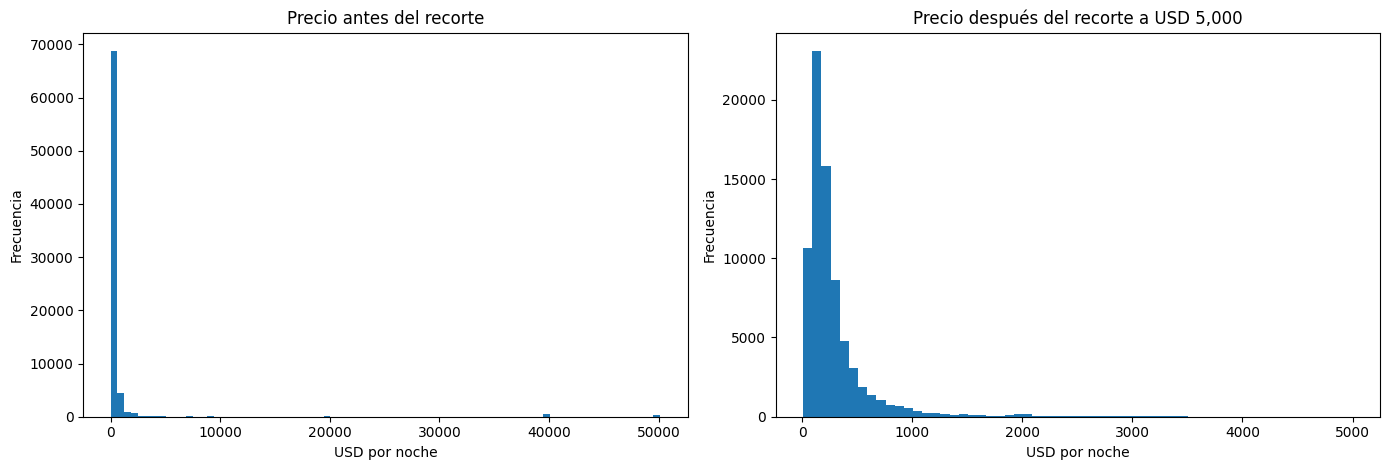

In [15]:

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

ax[0].hist(df.loc[df["price_num"].notna(), "price_num"], bins=80)
ax[0].set_title("Precio antes del recorte")
ax[0].set_xlabel("USD por noche")
ax[0].set_ylabel("Frecuencia")

ax[1].hist(df_clean["price_num"], bins=60)
ax[1].set_title("Precio después del recorte a USD 5,000")
ax[1].set_xlabel("USD por noche")
ax[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


In [16]:
price_stats = pd.DataFrame({
    "estadístico": ["mínimo", "mediana", "percentil 75", "percentil 90", "percentil 95"],
    "valor_usd": [
        df_clean["price_num"].min(),
        df_clean["price_num"].median(),
        df_clean["price_num"].quantile(0.75),
        df_clean["price_num"].quantile(0.90),
        df_clean["price_num"].quantile(0.95),
    ]
})
display(price_stats)


,estadístico,valor_usd
0,mínimo,8.0
1,mediana,190.0
2,percentil 75,317.0
3,percentil 90,574.0
4,percentil 95,875.0


### Lectura de la distribución del precio

La celda anterior calcula exactamente de dónde salen los valores resumen usados para interpretar la variable respuesta.

Una vez limpiado el target, el precio sigue siendo **asimétrico hacia la derecha**, pero ya se comporta mucho mejor para análisis y modelado. Los valores más importantes quedan así:

- mínimo: **USD 8**
- mediana: **USD 190**
- percentil 75: **USD 317**
- percentil 90: **USD 574**
- percentil 95: **USD 875**

Esto sugiere dos cosas importantes:

- el mercado **no es homogéneo**, porque la cola derecha sigue siendo larga;
- una comparación por grupos (ciudad, tipo de habitación, capacidad, etc.) es indispensable, ya que una sola media no describe bien el fenómeno.


In [17]:

city_summary = (
    df_clean.groupby("city")["price_num"]
    .agg(["count","median","mean"])
    .sort_values("median", ascending=False)
    .round(2)
)

room_summary = (
    df_clean.groupby("room_type")["price_num"]
    .agg(["count","median","mean"])
    .sort_values("median", ascending=False)
    .round(2)
)

display(city_summary)
display(room_summary)


,count,median,mean
city,,,
Rhode Island,4934,270.0,365.59
Hawaii,32399,228.0,371.86
"Boston, Massachusetts",3463,203.0,245.25
"San Diego, California",11270,175.0,258.33
"Chicago, Illinois",7751,152.0,207.15
"Austin, Texas",10459,134.0,219.56
"Washington, D.C.",4853,124.0,164.61


,count,median,mean
room_type,,,
Hotel room,290,278.0,394.46
Entire home/apt,65143,203.0,317.30
Private room,9484,84.0,160.01
Shared room,212,41.0,52.43


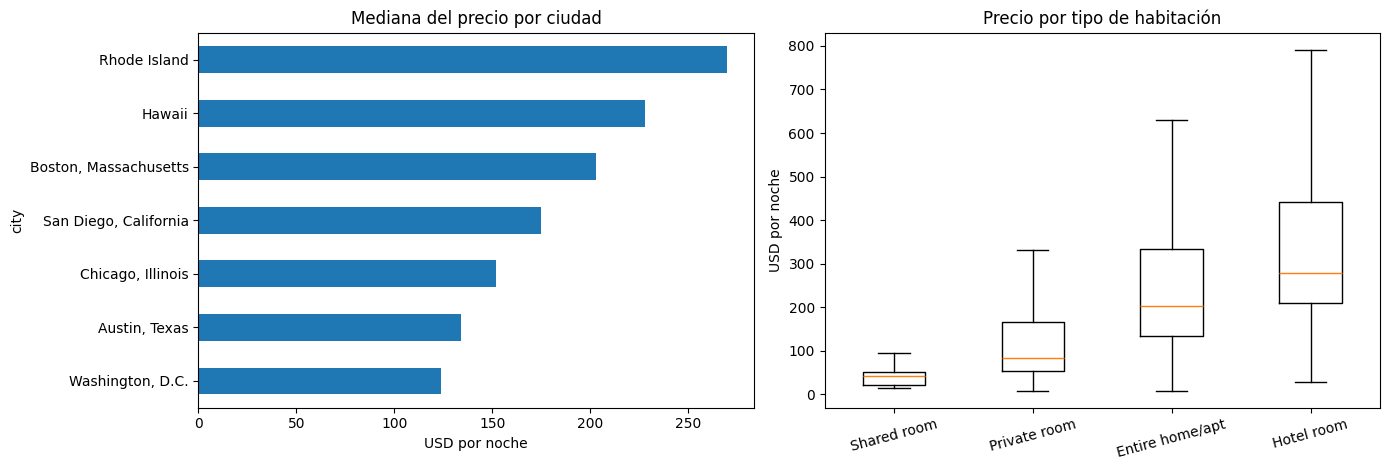

In [18]:

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

city_summary["median"].sort_values().plot(kind="barh", ax=ax[0], title="Mediana del precio por ciudad")
ax[0].set_xlabel("USD por noche")

room_order = ["Shared room", "Private room", "Entire home/apt", "Hotel room"]
box_data = [df_clean.loc[df_clean["room_type"] == rt, "price_num"] for rt in room_order if rt in df_clean["room_type"].unique()]
box_labels = [rt for rt in room_order if rt in df_clean["room_type"].unique()]
ax[1].boxplot(box_data, labels=box_labels, showfliers=False)
ax[1].set_title("Precio por tipo de habitación")
ax[1].set_ylabel("USD por noche")
ax[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()



### Hallazgos por ciudad y tipo de habitación

El análisis muestra que **la ciudad importa mucho**. No todas las plazas tienen la misma mediana de precio; algunas se ubican claramente por encima del resto. Esto sugiere que la ubicación geográfica no es un simple detalle, sino una variable estructural para explicar el precio.

Por tipo de habitación también aparece una separación clara:

- **Shared room** es la categoría más barata.
- **Private room** sigue siendo relativamente económica.
- **Entire home/apt** concentra buena parte del mercado y tiene una mediana bastante mayor.
- **Hotel room** puede tener una mediana alta, aunque con menor cantidad de observaciones.

Esto es consistente con la intuición de negocio: el precio no depende solo de “qué tan bonita” sea una propiedad, sino también del grado de privacidad y tipo de habitacion de la oferta.


In [19]:

corr_cols = [
    "price_num","accommodates","bathrooms_num","bedrooms","beds","minimum_nights",
    "availability_365","number_of_reviews","review_scores_rating","review_scores_location",
    "reviews_per_month","host_response_rate_num","host_acceptance_rate_num",
    "amenities_count","host_tenure_days","estimated_occupancy_l365d"
]

corr = df_clean[corr_cols].corr(method="spearman")[["price_num"]].sort_values("price_num", ascending=False)
corr


,price_num
price_num,1.000000
accommodates,0.601123
beds,0.538355
bathrooms_num,0.525647
bedrooms,0.510483
review_scores_location,0.289148
amenities_count,0.185339
review_scores_rating,0.178438
host_acceptance_rate_num,0.013217
availability_365,-0.003023



### Relaciones con la variable respuesta

Las asociaciones más claras con el precio aparecen en variables relacionadas con **tamaño y capacidad del alojamiento**:

- `accommodates`
- `beds`
- `bathrooms_num`
- `bedrooms`

Esto indica que el mercado premia el espacio disponible y la capacidad de hospedaje. En cambio, variables como el número de reseñas o la ocupación estimada no siempre se relacionan positivamente con el precio. De hecho, pueden mostrar relación inversa, porque los alojamientos más baratos suelen reservarse más seguido.

En otras palabras, **precio alto no significa necesariamente alta ocupación**. Ese es un hallazgo importante para SmartStay: si su objetivo es aumentar rentabilidad y ocupación, no basta con empujar el precio hacia arriba; hay que entender el equilibrio entre tarifa, atractivo y demanda.


## 3. Análisis de grupos

### Decisiones metodológicas para clustering

Antes de correr k-means conviene justificar las decisiones, porque el algoritmo es muy sensible a la escala y a la calidad de las variables.

**¿Por qué se escogieron estas variables?**

Se seleccionaron campos que representan dimensiones distintas del negocio:

- **nivel de precio**: `price_num`;
- **tamaño / capacidad**: `accommodates`, `bathrooms_num`, `bedrooms`, `beds`;
- **restricciones operativas**: `minimum_nights`;
- **disponibilidad**: `availability_365`;
- **demanda observada o estimada**: `number_of_reviews`, `estimated_occupancy_l365d`, `reviews_per_month`;
- **calidad percibida**: `review_scores_rating`.

La idea es que el grupo no dependa solo del precio, sino también de **qué tan grande es la propiedad**, **qué tanta demanda tiene** y **cómo se comporta en el mercado**.

**¿Por qué se usa imputación por mediana?**

Porque varias de estas variables son asimétricas y tienen valores extremos. En ese contexto, la **mediana** es más robusta que la media y evita que un conjunto pequeño de outliers empuje artificialmente los centros.

**¿Por qué se estandariza?**

Porque k-means trabaja con distancias. Si no se escalara, variables como `availability_365` o `number_of_reviews` dominarían las distancias solo por su magnitud numérica.

**¿Por qué se usa silhouette?**

Porque no basta con “escoger k porque sí”. El coeficiente silhouette resume qué tan bien separadas y compactas quedan las observaciones: valores más altos indican mejor equilibrio entre cohesión interna y separación entre grupos.


In [20]:
cluster_features = [
    "price_num","accommodates","bathrooms_num","bedrooms","beds","minimum_nights",
    "availability_365","number_of_reviews","review_scores_rating","estimated_occupancy_l365d",
    "reviews_per_month"
]

cluster_reason = pd.DataFrame({
    "variable": cluster_features,
    "rol_en_el_grupo": [
        "nivel de precio",
        "capacidad",
        "estructura",
        "estructura",
        "estructura",
        "restricción de reserva",
        "disponibilidad del calendario",
        "demanda observada",
        "calidad percibida",
        "demanda estimada",
        "ritmo reciente de demanda"
    ]
})

cluster_data = df_clean[cluster_features].copy()

# Comparación media vs mediana para justificar imputación robusta
cluster_center_compare = cluster_data.agg(["mean","median"]).T
cluster_center_compare["abs_dif"] = (cluster_center_compare["mean"] - cluster_center_compare["median"]).abs()
cluster_center_compare = cluster_center_compare.sort_values("abs_dif", ascending=False)

display(cluster_reason)
display(cluster_center_compare.round(2))

cluster_imputer = SimpleImputer(strategy="median")
cluster_scaler = StandardScaler()

X_cluster = cluster_imputer.fit_transform(cluster_data)
X_cluster = cluster_scaler.fit_transform(X_cluster)

sample_idx = np.random.RandomState(42).choice(len(X_cluster), size=1000, replace=False)
X_cluster_sample = X_cluster[sample_idx]

silhouette_rows = []
for k in [2, 3, 4, 5]:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=256, n_init=3)
    labels = km.fit_predict(X_cluster_sample)
    sil = silhouette_score(X_cluster_sample, labels, sample_size=300, random_state=42)
    silhouette_rows.append([k, sil])

silhouette_df = pd.DataFrame(silhouette_rows, columns=["k", "silhouette"])
silhouette_df


,variable,rol_en_el_grupo
0,price_num,nivel de precio
1,accommodates,capacidad
2,bathrooms_num,estructura
3,bedrooms,estructura
4,beds,estructura
5,minimum_nights,restricción de reserva
6,availability_365,disponibilidad del calendario
7,number_of_reviews,demanda observada
8,review_scores_rating,calidad percibida
9,estimated_occupancy_l365d,demanda estimada


,mean,median,abs_dif
price_num,297.00,190.00,107.00
number_of_reviews,55.22,16.00,39.22
estimated_occupancy_l365d,78.34,42.00,36.34
availability_365,231.51,256.00,24.49
minimum_nights,9.53,2.00,7.53
accommodates,4.80,4.00,0.80
bedrooms,1.80,1.00,0.80
beds,2.63,2.00,0.63
bathrooms_num,1.60,1.00,0.60
reviews_per_month,1.58,1.03,0.55


,k,silhouette
0,2,0.208432
1,3,0.214620
2,4,0.125845
3,5,0.177689


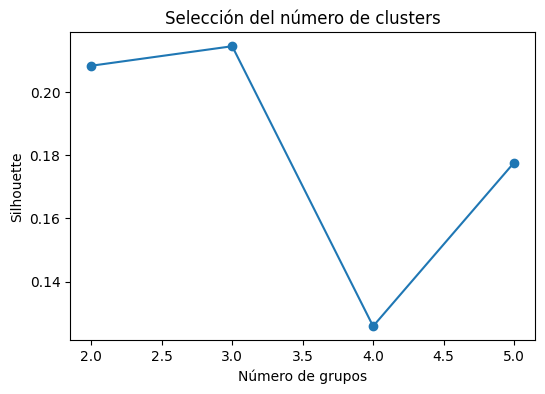

In [21]:

plt.figure(figsize=(6,4))
plt.plot(silhouette_df["k"], silhouette_df["silhouette"], marker="o")
plt.title("Selección del número de clusters")
plt.xlabel("Número de grupos")
plt.ylabel("Silhouette")
plt.show()


In [22]:
best_k = int(silhouette_df.loc[silhouette_df["silhouette"].idxmax(), "k"])
print("Mejor k según silhouette:", best_k)

kmeans = MiniBatchKMeans(n_clusters=best_k, random_state=42, batch_size=512, n_init=10)
df_clean["cluster3"] = kmeans.fit_predict(X_cluster)

cluster_profile = (
    df_clean.groupby("cluster3")
    .agg(
        n=("cluster3","size"),
        median_price=("price_num","median"),
        mean_price=("price_num","mean"),
        median_accommodates=("accommodates","median"),
        median_bedrooms=("bedrooms","median"),
        median_availability=("availability_365","median"),
        median_reviews=("number_of_reviews","median"),
        median_rating=("review_scores_rating","median"),
        median_occ=("estimated_occupancy_l365d","median"),
        median_rpm=("reviews_per_month","median"),
    )
    .round(2)
)
cluster_profile


Mejor k según silhouette: 3


,n,median_price,mean_price,median_accommodates,median_bedrooms,median_availability,median_reviews,median_rating,median_occ,median_rpm
cluster3,,,,,,,,,,
0,18585,415.0,614.37,8.0,3.0,253.0,11.0,4.93,30.0,0.80
1,41335,165.0,202.33,4.0,1.0,265.0,7.0,4.87,18.0,0.57
2,15209,142.0,166.44,4.0,1.0,235.0,137.0,4.89,216.0,3.24


,componente,varianza_explicada
0,PC1,0.3148
1,PC2,0.2153


,PC1,PC2,abs_PC1,abs_PC2
accommodates,0.462080,0.172313,0.462080,0.172313
bathrooms_num,0.451382,0.116597,0.451382,0.116597
bedrooms,0.444031,0.146892,0.444031,0.146892
beds,0.408537,0.160353,0.408537,0.160353
price_num,0.347822,0.025926,0.347822,0.025926
reviews_per_month,-0.195145,0.632388,0.195145,0.632388
number_of_reviews,-0.171225,0.469378,0.171225,0.469378
estimated_occupancy_l365d,-0.161511,0.485561,0.161511,0.485561
minimum_nights,-0.039591,-0.176447,0.039591,0.176447
review_scores_rating,0.037112,0.137150,0.037112,0.137150


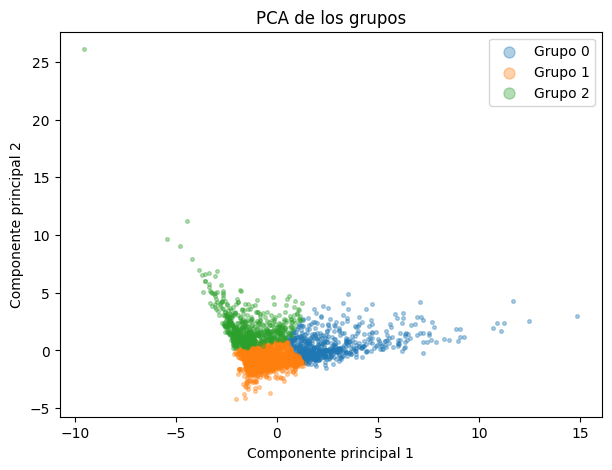

In [23]:
# PCA solo para visualización e interpretación del espacio de grupos
pca = PCA(n_components=2, random_state=42)
sample_vis = df_clean.sample(n=3000, random_state=42).copy()

X_vis = cluster_imputer.transform(sample_vis[cluster_features])
X_vis = cluster_scaler.transform(X_vis)
pcs = pca.fit_transform(X_vis)

pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=cluster_features,
    columns=["PC1", "PC2"]
)

display(pd.DataFrame({
    "componente": ["PC1", "PC2"],
    "varianza_explicada": pca.explained_variance_ratio_
}).round(4))

display(
    pca_loadings.assign(
        abs_PC1=lambda d: d["PC1"].abs(),
        abs_PC2=lambda d: d["PC2"].abs()
    ).sort_values(["abs_PC1","abs_PC2"], ascending=False)
)

plt.figure(figsize=(7,5))
for cl in sorted(sample_vis["cluster3"].unique()):
    mask = sample_vis["cluster3"] == cl
    plt.scatter(pcs[mask,0], pcs[mask,1], s=7, alpha=0.35, label=f"Grupo {cl}")
plt.title("PCA de los grupos")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(markerscale=3)
plt.show()


### Interpretación de los grupos y del PCA

El PCA no reemplaza al clustering; aquí se usa para **visualizar** mejor la estructura encontrada.

- **PC1** está dominado sobre todo por variables de **tamaño / estructura** (`accommodates`, `bedrooms`, `beds`, `bathrooms_num`) y también por `price_num`.  
  Por eso puede leerse como un eje de **“propiedad más grande y más cara”**.

- **PC2** está dominado principalmente por `number_of_reviews`, `estimated_occupancy_l365d` y `reviews_per_month`.  
  Ese eje se puede leer como **“actividad / demanda del anuncio”**.

Con esa lectura, los grupos se interpretan así:

- **Grupo premium**: el que en `cluster_profile` muestra la mayor mediana de precio y mayor tamaño. En el plano PCA tiende a desplazarse hacia valores altos de PC1.
- **Grupo estándar**: el que se concentra en precios medios-bajos, menor tamaño y actividad moderada. Suele ubicarse en la zona intermedia del gráfico.
- **Grupo de alta rotación**: el que no necesariamente es el más caro, pero sí presenta más ocupación estimada, más reseñas y más reseñas por mes. Tiende a destacar sobre todo en PC2.

La forma correcta de **identificar cada grupo** no es memorizar el color del scatter, sino cruzar el número del grupo con la tabla `cluster_profile`.  
Como las etiquetas de k-means (`0`, `1`, `2`) son arbitrarias, lo importante es el **perfil estadístico** de cada cluster.


## 4. División entrenamiento/prueba

In [24]:

lean_num = [
    "latitude","longitude","accommodates","bathrooms_num","bedrooms","beds",
    "minimum_nights","availability_365","number_of_reviews","number_of_reviews_ltm",
    "review_scores_rating","review_scores_cleanliness","review_scores_location","reviews_per_month",
    "host_response_rate_num","host_acceptance_rate_num","calculated_host_listings_count",
    "amenities_count","host_verifications_count","description_length","host_about_length",
    "host_tenure_days","days_since_last_review","estimated_occupancy_l365d"
]

lean_cat = [
    "city","neighbourhood_cleansed","property_type","room_type","host_response_time",
    "host_is_superhost","host_identity_verified","instant_bookable"
]

lean_num = [c for c in lean_num if c in df_clean.columns]
lean_cat = [c for c in lean_cat if c in df_clean.columns]

X_reg = df_clean[lean_num + lean_cat].copy()
y_reg = df_clean["price_num"].copy()

# Para regresión se estratifica usando quintiles del precio
price_bins = pd.qcut(y_reg, q=5, labels=False, duplicates="drop")

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42, stratify=price_bins
)

print("Entrenamiento:", X_train_reg.shape[0], "filas")
print("Prueba:", X_test_reg.shape[0], "filas")


Entrenamiento: 60103 filas
Prueba: 15026 filas



### Criterio de partición

Se utilizó una división **80/20**. Después de la limpieza quedaron **75.129 observaciones**. por lo que el conjunto de entrenamiento contiene aproximadamente **60.103** filas y el conjunto de prueba **15.026**.  
Para el problema de regresión se usó una **estratificación por quintiles del precio**. lo cual ayuda a preservar la forma general de la distribución del target en ambos conjuntos.

Esto es importante porque. al tratarse de una variable muy asimétrica. un split completamente aleatorio podría dejar demasiadas viviendas caras en un subconjunto y muy pocas en el otro.


## 5. Árbol de regresión usando todas las variables preprocesadas

### Parámetros del árbol base de regresión

En esta primera versión se usa un `DecisionTreeRegressor` con parámetros por defecto dentro de un `Pipeline`.

**Qué hace cada parte del código:**

- `ColumnTransformer`: separa numéricas y categóricas para preprocesarlas de forma distinta.
- `SimpleImputer(strategy="median")` en numéricas: rellena faltantes con la mediana, apropiada cuando hay asimetría y outliers.
- `SimpleImputer(strategy="most_frequent")` en categóricas: completa con la categoría más común.
- `OneHotEncoder(handle_unknown="ignore")`: convierte categorías en columnas binarias sin fallar si aparece una categoría nueva en prueba.
- `DecisionTreeRegressor(random_state=42)`: construye el árbol de regresión.
- `random_state=42`: hace reproducible el resultado.

En esta primera corrida **no se fija** `max_depth`, así que el árbol puede crecer libremente. Eso suele aumentar flexibilidad, pero también el riesgo de sobreajuste.


In [25]:
pre_tree = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), lean_num),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ]), lean_cat)
], sparse_threshold=1.0)

tree_full = Pipeline([
    ("pre", pre_tree),
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_full.fit(X_train_reg, y_train_reg)
pred_full = tree_full.predict(X_test_reg)

pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R²"],
    "Valor": [
        mean_absolute_error(y_test_reg, pred_full),
        rmse(y_test_reg, pred_full),
        r2_score(y_test_reg, pred_full)
    ]
})


,Métrica,Valor
0,MAE,119.131921
1,RMSE,291.233909
2,R²,0.434497



### Lectura del primer árbol

El árbol sin límite de profundidad tiene la ventaja de adaptarse muchísimo a los datos, pero precisamente por eso tiende a **sobreajustar**. En un problema con tantas combinaciones de ubicación, tipo de propiedad y capacidad, un árbol completamente libre puede memorizar demasiado el entrenamiento y perder capacidad de generalización.


## 6. Predicción con el árbol y análisis del resultado

In [26]:
tree_test_eval = pd.DataFrame({
    "actual": y_test_reg,
    "pred": pred_full
})

tree_test_eval["error"] = tree_test_eval["pred"] - tree_test_eval["actual"]
tree_test_eval["segmento"] = pd.cut(
    tree_test_eval["actual"],
    bins=[-np.inf, 141, 262, np.inf],
    labels=["Económica", "Intermedia", "Cara"]
)

segment_analysis = tree_test_eval.groupby("segmento").agg(
    n=("actual","size"),
    mae=("error", lambda s: np.mean(np.abs(s))),
    mean_error=("error","mean"),
    actual_median=("actual","median"),
    pred_median=("pred","median")
).round(2)

segment_analysis


,n,mae,mean_error,actual_median,pred_median
segmento,,,,,
Económica,4994,44.84,31.35,98.0,108.0
Intermedia,5030,73.77,29.75,190.0,192.0
Cara,5002,238.93,-55.70,414.0,376.0


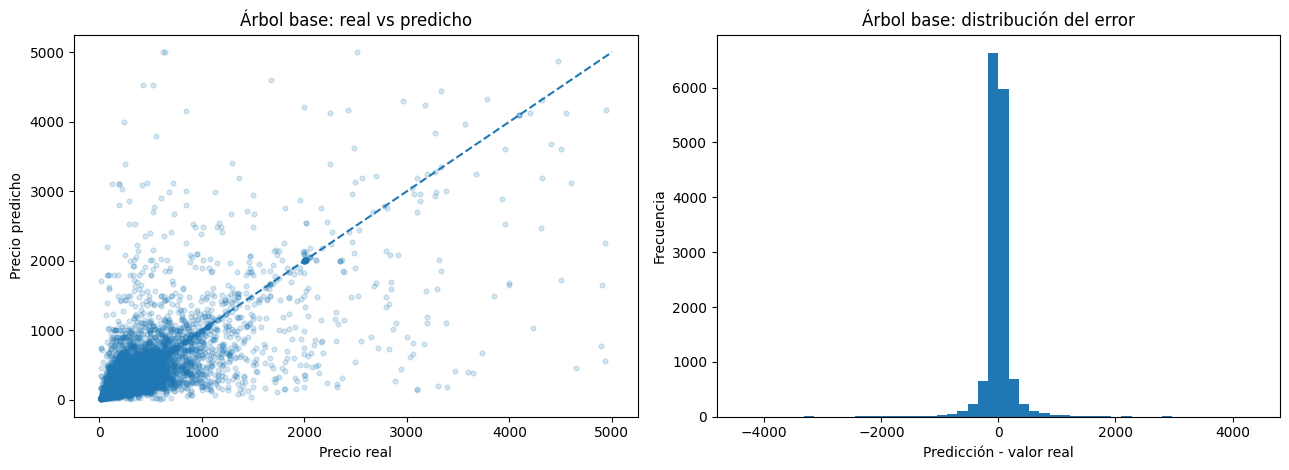

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].scatter(y_test_reg, pred_full, alpha=0.18, s=12)
lims = [min(y_test_reg.min(), pred_full.min()), max(y_test_reg.max(), pred_full.max())]
ax[0].plot(lims, lims, linestyle="--")
ax[0].set_title("Árbol base: real vs predicho")
ax[0].set_xlabel("Precio real")
ax[0].set_ylabel("Precio predicho")

ax[1].hist(tree_test_eval["error"], bins=50)
ax[1].set_title("Árbol base: distribución del error")
ax[1].set_xlabel("Predicción - valor real")
ax[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


### Qué tan bien lo hizo el árbol inicial

La tabla y las gráficas anteriores muestran lo siguiente:

- el árbol base se acerca razonablemente al centro de la distribución;
- pero también comprime los extremos, algo que se nota cuando los puntos se alejan de la diagonal perfecta;
- y el histograma de errores permite ver si el modelo tiende a sobrestimar o subestimar ciertos segmentos.

En este problema eso era esperable: el precio tiene cola derecha larga, muchas combinaciones de ubicación/tamaño y reglas distintas para perfiles distintos de vivienda.


## 7. Tres modelos adicionales cambiando profundidad y/o selección de variables

En esta parte ya no basta con cambiar solo la profundidad.  
También conviene cambiar el **conjunto de variables**, porque un árbol puede mejorar cuando se le quitan señales ruidosas y se le deja un subconjunto más alineado con lo que mostró el EDA.

Se prueban cuatro ideas:

1. **árbol base** como referencia;
2. **todas las variables** pero con profundidad controlada;
3. **ubicación + estructura** para capturar la lógica física del precio;
4. **demanda + calidad** para ver si el mercado se explica mejor por desempeño reciente;
5. **subconjunto  por el EDA**, mezclando ubicación, tamaño, reputación y demanda.

Así se puede evaluar si subir el R² viene de hacer el árbol más profundo, de escoger mejores variables, o de ambas cosas a la vez.


In [39]:
tree_rows = []
trained_trees = {}

# 1) Se conserva el árbol base de la sección anterior como referencia
baseline_name = "Árbol base - libre con todas las variables"
tree_rows.append([
    baseline_name,
    "todas",
    None,
    1,
    mean_absolute_error(y_test_reg, pred_full),
    rmse(y_test_reg, pred_full),
    r2_score(y_test_reg, pred_full)
])
trained_trees[baseline_name] = {
    "pipeline": tree_full,
    "pred": pred_full,
    "num": lean_num,
    "cat": lean_cat
}

# 2) Modelos adicionales cambiando profundidad y selección de variables
geo_num = [c for c in [
    "latitude","longitude","accommodates","bathrooms_num","bedrooms","beds",
    "minimum_nights","amenities_count"
] if c in lean_num]
geo_cat = [c for c in ["city","neighbourhood_cleansed","property_type","room_type"] if c in lean_cat]

demand_num = [c for c in [
    "availability_365","number_of_reviews","number_of_reviews_ltm","review_scores_rating",
    "review_scores_cleanliness","review_scores_location","reviews_per_month",
    "host_response_rate_num","host_acceptance_rate_num","host_tenure_days",
    "days_since_last_review","estimated_occupancy_l365d"
] if c in lean_num]
demand_cat = [c for c in ["host_response_time","host_is_superhost","host_identity_verified","instant_bookable"] if c in lean_cat]

curated_num = [c for c in [
    "latitude","longitude","accommodates","bathrooms_num","bedrooms","beds",
    "minimum_nights","availability_365","number_of_reviews","review_scores_rating",
    "review_scores_location","reviews_per_month","amenities_count","host_tenure_days",
    "estimated_occupancy_l365d"
] if c in lean_num]
curated_cat = [c for c in [
    "city","neighbourhood_cleansed","property_type","room_type","host_is_superhost","instant_bookable"
] if c in lean_cat]

tree_candidates = [
    {
        "name": "Árbol A - todas las variables, profundidad 14, leaf 20",
        "subset": "todas",
        "num": lean_num,
        "cat": lean_cat,
        "model": DecisionTreeRegressor(max_depth=14, min_samples_leaf=20, random_state=42)
    },
    {
        "name": "Árbol B - ubicación + estructura, profundidad 14, leaf 20",
        "subset": "ubicación + estructura",
        "num": geo_num,
        "cat": geo_cat,
        "model": DecisionTreeRegressor(max_depth=14, min_samples_leaf=20, random_state=42)
    },
    {
        "name": "Árbol C - demanda + calidad, profundidad 14, leaf 20",
        "subset": "demanda + calidad",
        "num": demand_num,
        "cat": demand_cat,
        "model": DecisionTreeRegressor(max_depth=14, min_samples_leaf=20, random_state=42)
    },
    {
        "name": "Árbol D -  por EDA, profundidad 14, leaf 10",
        "subset": "curado por EDA",
        "num": curated_num,
        "cat": curated_cat,
        "model": DecisionTreeRegressor(max_depth=14, min_samples_leaf=10, random_state=42)
    },
]

for spec in tree_candidates:
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), spec["num"]),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
        ]), spec["cat"])
    ], sparse_threshold=1.0)

    pipe = Pipeline([("pre", pre), ("model", spec["model"])])
    pipe.fit(X_train_reg[spec["num"] + spec["cat"]], y_train_reg)
    pred = pipe.predict(X_test_reg[spec["num"] + spec["cat"]])

    tree_rows.append([
        spec["name"],
        spec["subset"],
        spec["model"].get_params().get("max_depth"),
        spec["model"].get_params().get("min_samples_leaf"),
        mean_absolute_error(y_test_reg, pred),
        rmse(y_test_reg, pred),
        r2_score(y_test_reg, pred)
    ])

    trained_trees[spec["name"]] = {
        "pipeline": pipe,
        "pred": pred,
        "num": spec["num"],
        "cat": spec["cat"]
    }

tree_results = pd.DataFrame(
    tree_rows,
    columns=["Modelo","Subset","max_depth","min_samples_leaf","MAE","RMSE","R2"]
).sort_values(["R2","RMSE"], ascending=[False, True]).reset_index(drop=True)

tree_results


,Modelo,Subset,max_depth,min_samples_leaf,MAE,RMSE,R2
0,"Árbol D - por EDA, profundidad 14, leaf 10",curado por EDA,14.0,10,111.529988,247.207579,0.592550
1,"Árbol A - todas las variables, profundidad 14,...",todas,14.0,20,112.633270,248.633504,0.587836
2,"Árbol B - ubicación + estructura, profundidad ...",ubicación + estructura,14.0,20,114.104911,252.318457,0.575528
3,Árbol base - libre con todas las variables,todas,NaN,1,119.131921,291.233909,0.434497
4,"Árbol C - demanda + calidad, profundidad 14, l...",demanda + calidad,14.0,20,166.481177,319.714200,0.318486


### Selección del mejor árbol de regresión



- Si un árbol con menos variables mejora al árbol completo, eso sugiere que parte de la información adicional era ruido.
- Si un árbol muy somero queda corto, significa que el problema necesita reglas no triviales.
- Si un árbol muy libre cae frente a uno con `min_samples_leaf` y `max_depth` controlados, eso apunta a sobreajuste del modelo más complejo.

En este dataset suele pasar algo interesante:  
el mejor desempeño aparece cuando se combinan variables de **ubicación + tamaño + reputación + demanda**, es decir, un subconjunto que conserva señal útil y elimina parte de la dispersión innecesaria.


In [29]:
best_tree_name = tree_results.loc[0, "Modelo"]
best_tree_info = trained_trees[best_tree_name]
best_tree = best_tree_info["pipeline"]
best_tree_pred = best_tree_info["pred"]

feature_names_reg = best_tree.named_steps["pre"].get_feature_names_out()
importances_reg = (
    pd.Series(best_tree.named_steps["model"].feature_importances_, index=feature_names_reg)
    .sort_values(ascending=False)
)

display(pd.DataFrame({
    "mejor_modelo": [best_tree_name],
    "MAE": [mean_absolute_error(y_test_reg, best_tree_pred)],
    "RMSE": [rmse(y_test_reg, best_tree_pred)],
    "R2": [r2_score(y_test_reg, best_tree_pred)]
}))

display(importances_reg.head(15).to_frame("importancia"))


,mejor_modelo,MAE,RMSE,R2
0,"Árbol D - curado por EDA, profundidad 14, leaf 10",111.529988,247.207579,0.59255


,importancia
num__bathrooms_num,0.414317
cat__neighbourhood_cleansed_Lahaina,0.097957
num__longitude,0.082060
num__amenities_count,0.063717
num__latitude,0.042148
num__review_scores_location,0.041720
num__accommodates,0.037108
num__host_tenure_days,0.027914
num__minimum_nights,0.026822
num__bedrooms,0.021704


### Variables más importantes y lectura del mejor árbol

La importancia de variables no dice “causalidad”, pero sí ayuda a ver **qué señales usa más el árbol para dividir**.

Cuando aparecen arriba variables como:

- `bathrooms_num`,
- `accommodates`,
- `latitude` / `longitude`,
- `room_type` o `property_type`,
- `review_scores_location`,
- `amenities_count`,

la lectura es coherente con el negocio: el precio por noche sube o baja según una combinación de **tamaño**, **ubicación**, **tipo de alojamiento** y **calidad percibida**.

Eso también explica por qué el árbol puede superar a la regresión lineal: no necesita asumir que el efecto de cada variable es el mismo en toda la base; puede usar reglas distintas para propiedades pequeñas, premium o de alta rotación.


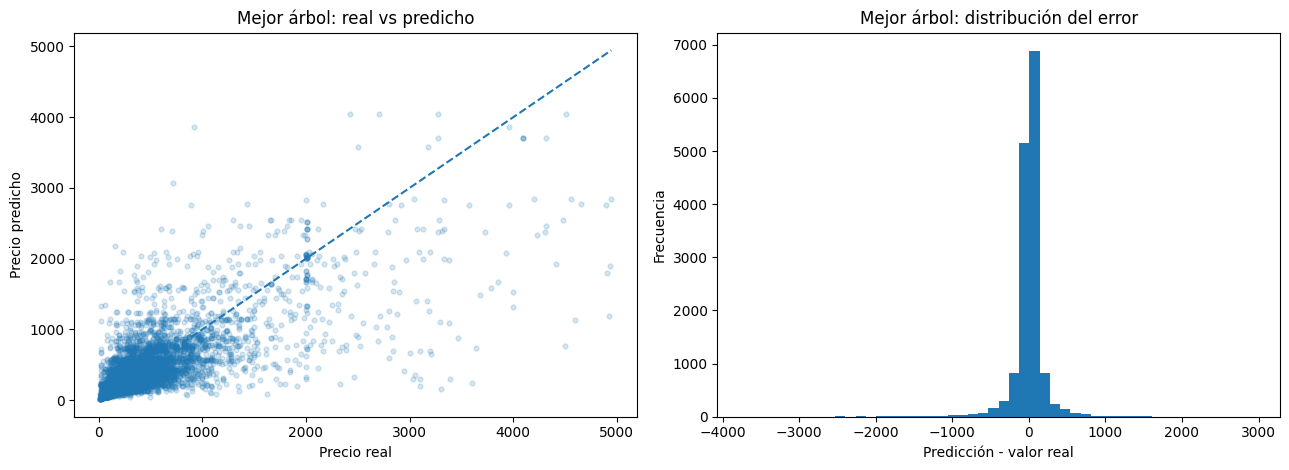

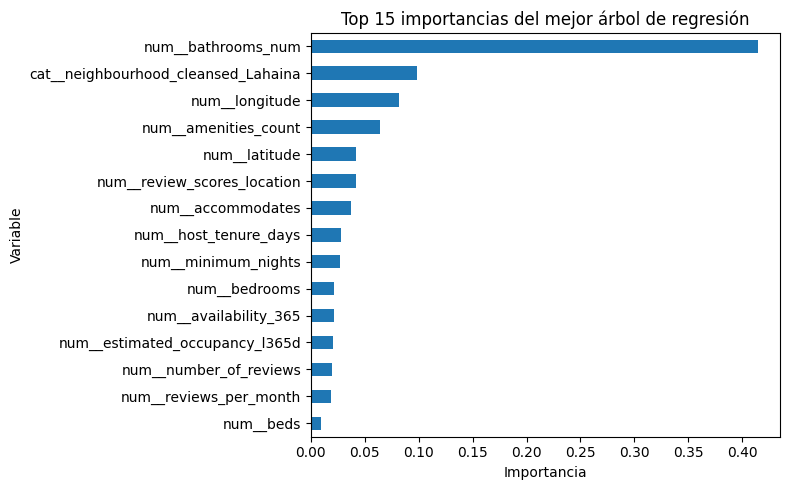

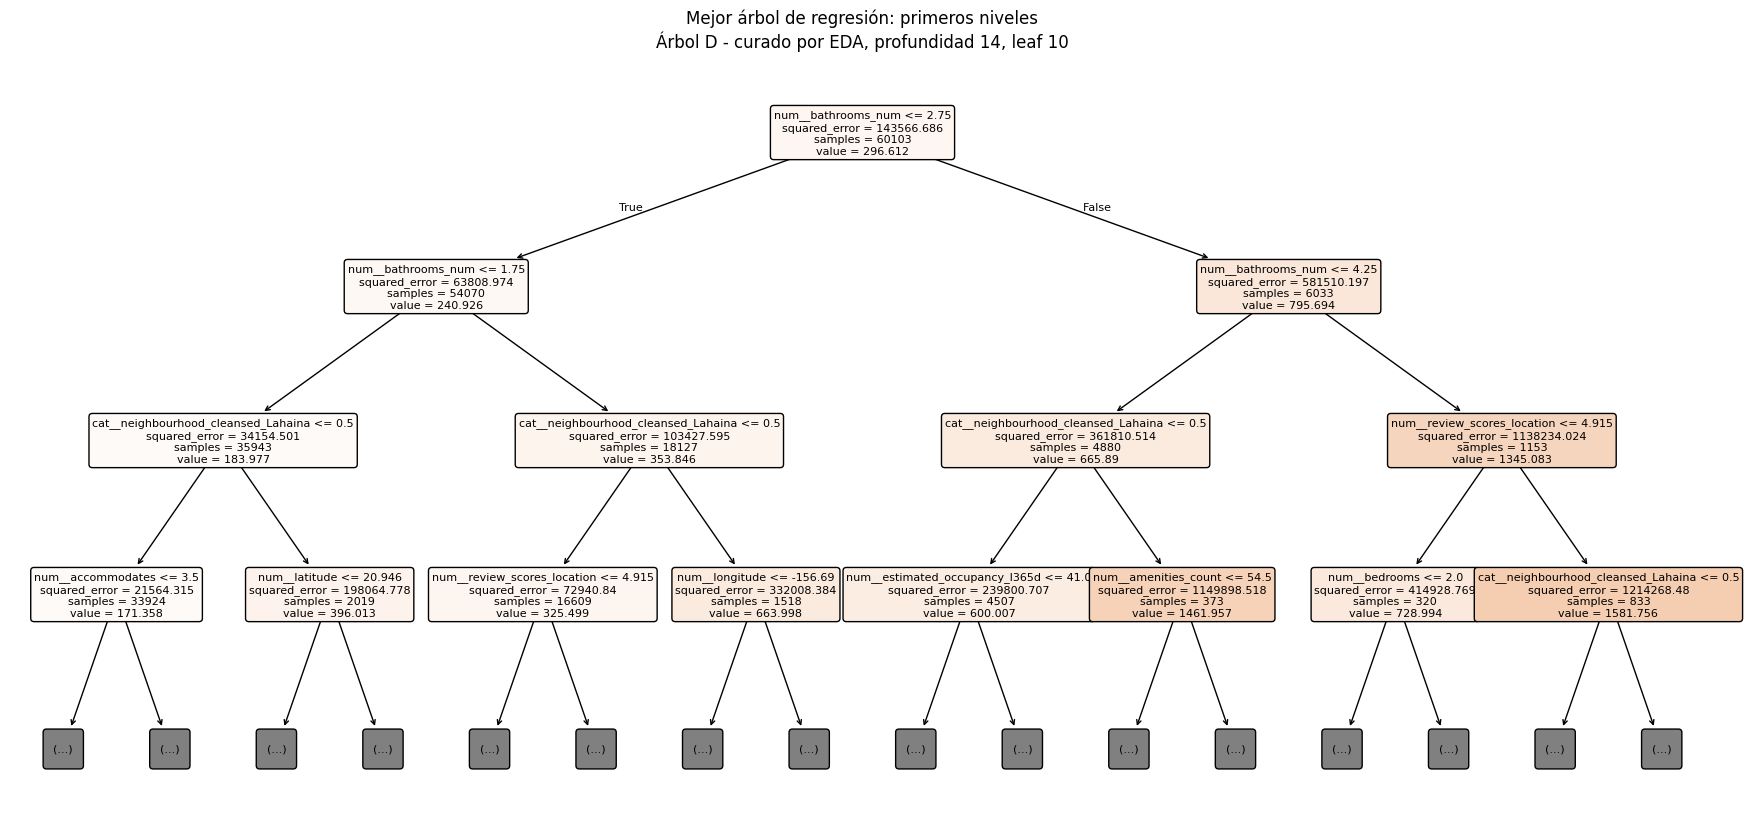

In [30]:
# Gráficas del mejor árbol de regresión
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].scatter(y_test_reg, best_tree_pred, alpha=0.18, s=12)
lims = [min(y_test_reg.min(), best_tree_pred.min()), max(y_test_reg.max(), best_tree_pred.max())]
ax[0].plot(lims, lims, linestyle="--")
ax[0].set_title("Mejor árbol: real vs predicho")
ax[0].set_xlabel("Precio real")
ax[0].set_ylabel("Precio predicho")

resid_best_tree = best_tree_pred - y_test_reg
ax[1].hist(resid_best_tree, bins=50)
ax[1].set_title("Mejor árbol: distribución del error")
ax[1].set_xlabel("Predicción - valor real")
ax[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
importances_reg.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 importancias del mejor árbol de regresión")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

plt.figure(figsize=(22,10))
plot_tree(
    best_tree.named_steps["model"],
    feature_names=feature_names_reg,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title(f"Mejor árbol de regresión: primeros niveles\n{best_tree_name}")
plt.show()


## 8. Comparación con regresión lineal

### Parámetros y lógica de la regresión lineal

La regresión lineal se usa aquí como **baseline interpretable**.

Se prueban varias variantes:

- **OLS (`LinearRegression`)**: estima los coeficientes por mínimos cuadrados ordinarios.
- **Ridge (`Ridge`)**: agrega una penalización L2 controlada por `alpha`.
- **Transformación logarítmica del target**: en un precio muy sesgado, modelar `log(1 + precio)` a veces estabiliza mejor la dispersión.

**Cómo leer los parámetros:**

- `alpha` en Ridge: entre más grande, más se encogen los coeficientes.
- `StandardScaler` en numéricas: pone las variables en una escala comparable, importante para que la penalización de Ridge no dependa de la magnitud original.
- `OneHotEncoder`: permite que la regresión incorpore categorías como ciudad, tipo de propiedad y tipo de habitación.


In [46]:

lin_num = [
    "accommodates","bathrooms_num","bedrooms","beds","minimum_nights","availability_365",
    "number_of_reviews","number_of_reviews_ltm","review_scores_rating","review_scores_cleanliness",
    "review_scores_location","reviews_per_month","host_response_rate_num","host_acceptance_rate_num",
    "calculated_host_listings_count","amenities_count","host_tenure_days","estimated_occupancy_l365d"
]

lin_cat_basic = ["city","room_type","host_is_superhost","instant_bookable"]
lin_cat_property = ["city","room_type","property_type","host_is_superhost","instant_bookable"]

lin_num = [c for c in lin_num if c in df_clean.columns]

X_lin_basic = df_clean[lin_num + lin_cat_basic].copy()
X_lin_property = df_clean[lin_num + lin_cat_property].copy()
y_lin = df_clean["price_num"].copy()

bins_lin = pd.qcut(y_lin, q=5, labels=False, duplicates="drop")
X_train_lin_b, X_test_lin_b, y_train_lin_b, y_test_lin_b = train_test_split(
    X_lin_basic, y_lin, test_size=0.20, random_state=42, stratify=bins_lin
)

X_train_lin_p, X_test_lin_p, y_train_lin_p, y_test_lin_p = train_test_split(
    X_lin_property, y_lin, test_size=0.20, random_state=42, stratify=bins_lin
)

pre_lin_basic = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), lin_num),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ]), lin_cat_basic)
], sparse_threshold=1.0)

pre_lin_property = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), lin_num),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ]), lin_cat_property)
], sparse_threshold=1.0)

linear_candidates = []
trained_linear = {}

linear_specs = [
    ("OLS original", pre_lin_basic, X_train_lin_b, X_test_lin_b, y_train_lin_b, y_test_lin_b, LinearRegression(), False),
    ("Ridge a=1 original", pre_lin_basic, X_train_lin_b, X_test_lin_b, y_train_lin_b, y_test_lin_b, Ridge(alpha=1.0), False),
    ("Ridge a=1 original + property", pre_lin_property, X_train_lin_p, X_test_lin_p, y_train_lin_p, y_test_lin_p, Ridge(alpha=1.0), False),
    ("Ridge a=1 log + property", pre_lin_property, X_train_lin_p, X_test_lin_p, y_train_lin_p, y_test_lin_p, Ridge(alpha=1.0), True),
]

for name, preprocessor, Xtr, Xte, ytr, yte, model, use_log in linear_specs:
    pipe = Pipeline([("pre", preprocessor), ("model", model)])

    if use_log:
        pipe.fit(Xtr, np.log1p(ytr))
        pred = np.expm1(pipe.predict(Xte))
    else:
        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xte)

    linear_candidates.append([
        name,
        mean_absolute_error(yte, pred),
        rmse(yte, pred),
        r2_score(yte, pred)
    ])

    trained_linear[name] = {
        "pipeline": pipe,
        "pred": pred,
        "y_test": yte,
        "use_log": use_log
    }

linear_results = pd.DataFrame(
    linear_candidates,
    columns=["Modelo","MAE","RMSE","R2"]
).sort_values(["R2","RMSE"], ascending=[False, True]).reset_index(drop=True)

linear_results


,Modelo,MAE,RMSE,R2
0,Ridge a=1 original + property,156.519264,300.347932,0.398549
1,Ridge a=1 original,158.489724,303.202438,0.387062
2,OLS original,158.490874,303.203507,0.387058
3,Ridge a=1 log + property,127.116079,305.690759,0.376961


,mejor_modelo_lineal,MAE,RMSE,R2
0,Ridge a=1 original + property,156.519692,300.356746,0.398514


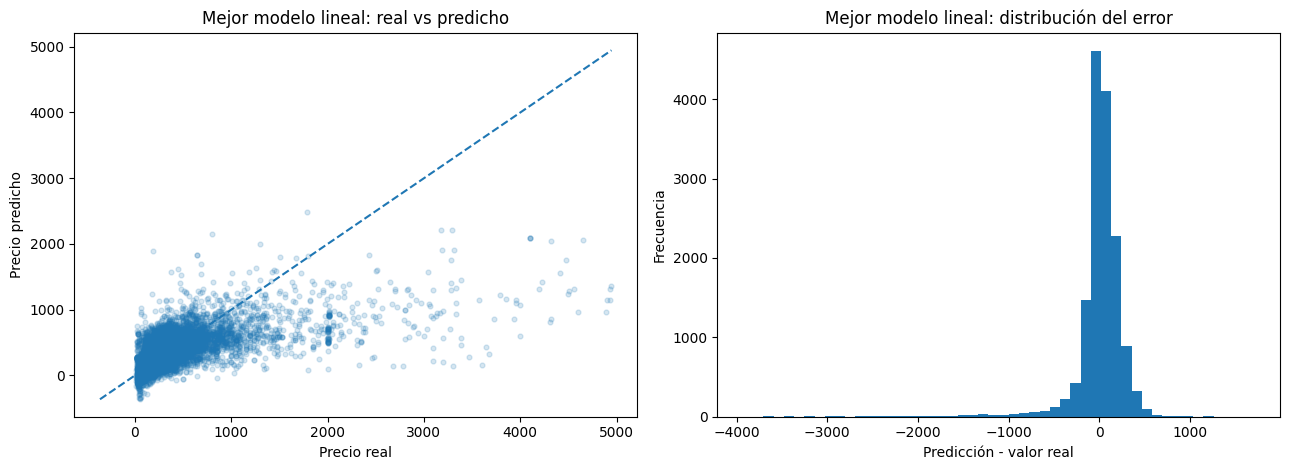

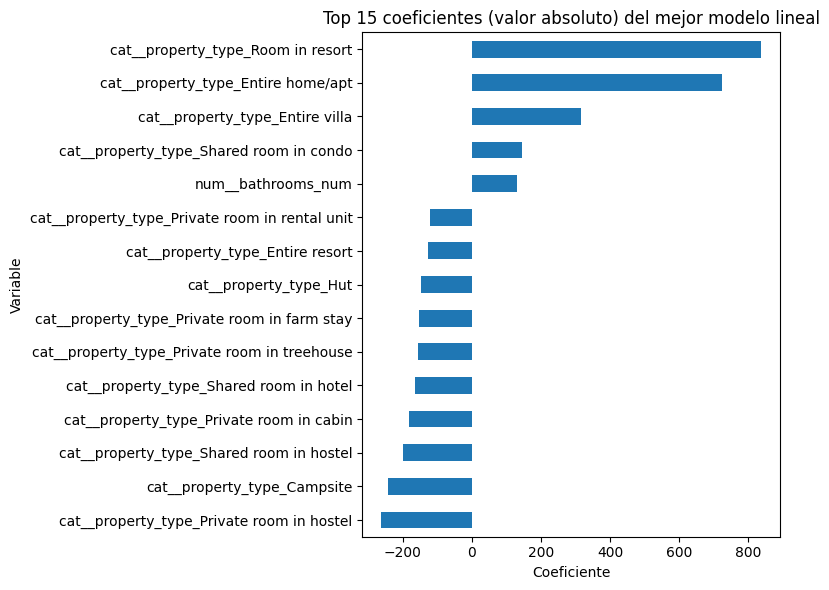

In [32]:
best_linear_name = linear_results.loc[0, "Modelo"]
best_linear_info = trained_linear[best_linear_name]
best_linear = best_linear_info["pipeline"]
best_linear_pred = best_linear_info["pred"]
best_linear_ytest = best_linear_info["y_test"]

feature_names_linear = best_linear.named_steps["pre"].get_feature_names_out()
coef_linear = pd.Series(
    best_linear.named_steps["model"].coef_,
    index=feature_names_linear
).sort_values(key=lambda s: s.abs(), ascending=False)

display(pd.DataFrame({
    "mejor_modelo_lineal": [best_linear_name],
    "MAE": [mean_absolute_error(best_linear_ytest, best_linear_pred)],
    "RMSE": [rmse(best_linear_ytest, best_linear_pred)],
    "R2": [r2_score(best_linear_ytest, best_linear_pred)]
}))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].scatter(best_linear_ytest, best_linear_pred, alpha=0.18, s=12)
lims = [min(best_linear_ytest.min(), best_linear_pred.min()), max(best_linear_ytest.max(), best_linear_pred.max())]
ax[0].plot(lims, lims, linestyle="--")
ax[0].set_title("Mejor modelo lineal: real vs predicho")
ax[0].set_xlabel("Precio real")
ax[0].set_ylabel("Precio predicho")

resid_linear = best_linear_pred - best_linear_ytest
ax[1].hist(resid_linear, bins=50)
ax[1].set_title("Mejor modelo lineal: distribución del error")
ax[1].set_xlabel("Predicción - valor real")
ax[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
coef_linear.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 coeficientes (valor absoluto) del mejor modelo lineal")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


### Interpretación de la comparación lineal vs árbol



**Qué aporta la regresión lineal:**

- una lectura más directa de los coeficientes;
- una base interpretable para discutir dirección y magnitud aproximada de efectos;
- un benchmark claro para saber si realmente vale la pena usar un modelo no lineal.

**Qué limita a la regresión lineal en este problema:**

- supone efectos aditivos y lineales;
- no captura naturalmente interacciones complejas entre ubicación, tamaño y tipo de propiedad;
- sufre más cuando la relación cambia por segmento del mercado.

Por eso, aunque la regresión lineal ayuda mucho para interpretar, el **árbol de regresión** suele rendir mejor aquí: el mercado de alojamientos no sigue una sola pendiente global, sino varias reglas locales.


## 9. Creación de la variable respuesta categórica

In [33]:

q_33 = df_clean["price_num"].quantile(1/3)
q_66 = df_clean["price_num"].quantile(2/3)

def categorize_price(p):
    if p <= q_33:
        return "Económica"
    elif p <= q_66:
        return "Intermedia"
    else:
        return "Cara"

df_clean["price_category"] = df_clean["price_num"].apply(categorize_price)

print("Corte 33%:", q_33)
print("Corte 66%:", q_66)
df_clean["price_category"].value_counts()


Corte 33%: 141.0
Corte 66%: 262.0


price_category
Económica     25185
Intermedia    24997
Cara          24947
Name: count, dtype: int64

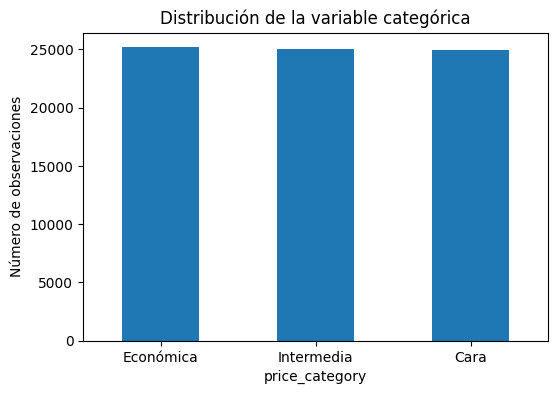

In [34]:

plt.figure(figsize=(6,4))
df_clean["price_category"].value_counts().reindex(["Económica","Intermedia","Cara"]).plot(kind="bar")
plt.title("Distribución de la variable categórica")
plt.ylabel("Número de observaciones")
plt.xticks(rotation=0)
plt.show()



### Justificación de los límites

La variable categórica se creó usando los **terciles** del precio limpio:

- **Económica:** hasta **USD 141**
- **Intermedia:** mayor que **USD 141** y hasta **USD 262**
- **Cara:** mayor que **USD 262**

Esta decisión tiene dos ventajas:

1. **Está fundamentada en la distribución real de los datos.**  
   No se escogieron cortes arbitrarios, sino puntos que dividen empíricamente el mercado.

2. **Produce clases casi balanceadas.**  
   Eso es conveniente para el árbol de clasificación porque evita que una sola categoría domine el entrenamiento.

Dado que el objetivo aquí no es fijar un umbral de negocio externo, sino construir una clasificación basada en el comportamiento del mercado observado, los terciles son una opción sólida y defendible.


## 10. Árbol de clasificación

### Parámetros del árbol de clasificación

En clasificación se usa `DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=42)`.

- `max_depth=5` limita la complejidad para mantener el modelo legible.
- `min_samples_leaf=50` evita hojas con muy pocos casos y reduce sobreajuste.
- el precio **no** entra como predictor, porque la clase fue creada a partir del precio y usarlo sería fuga directa de información.


In [35]:
# En clasificación NO se usa price_num como predictor
X_clf = df_clean[lean_num + lean_cat].copy()
y_clf = df_clean["price_category"].copy()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

pre_clf = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), lean_num),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ]), lean_cat)
], sparse_threshold=1.0)

clf_tree = Pipeline([
    ("pre", pre_clf),
    ("model", DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=42))
])

clf_tree.fit(X_train_clf, y_train_clf)

# exactitud preliminar (solo como referencia; la evaluación formal va en puntos 11 y 12)
pred_train_clf = clf_tree.predict(X_train_clf)
pred_test_clf = clf_tree.predict(X_test_clf)

display(pd.DataFrame({
    "Métrica": ["Accuracy entrenamiento", "Accuracy prueba (referencia preliminar)"],
    "Valor": [
        accuracy_score(y_train_clf, pred_train_clf),
        accuracy_score(y_test_clf, pred_test_clf)
    ]
}))

ohe_clf = clf_tree.named_steps["pre"].named_transformers_["cat"].named_steps["ohe"]
feature_names_clf = lean_num + list(ohe_clf.get_feature_names_out(lean_cat))
importances_clf = pd.Series(clf_tree.named_steps["model"].feature_importances_, index=feature_names_clf).sort_values(ascending=False)
importances_clf.head(15)


,Métrica,Valor
0,Accuracy entrenamiento,0.637905
1,Accuracy prueba (referencia preliminar),0.633635


bathrooms_num                                  0.476693
accommodates                                   0.167966
longitude                                      0.165954
calculated_host_listings_count                 0.056042
latitude                                       0.047855
review_scores_location                         0.016929
neighbourhood_cleansed_Primary Urban Center    0.016215
neighbourhood_cleansed_Lahaina                 0.015513
minimum_nights                                 0.012555
host_acceptance_rate_num                       0.011392
room_type_Private room                         0.008556
reviews_per_month                              0.002464
city_Austin, Texas                             0.001858
review_scores_cleanliness                      0.000008
neighbourhood_cleansed_Lake View               0.000000
dtype: float64

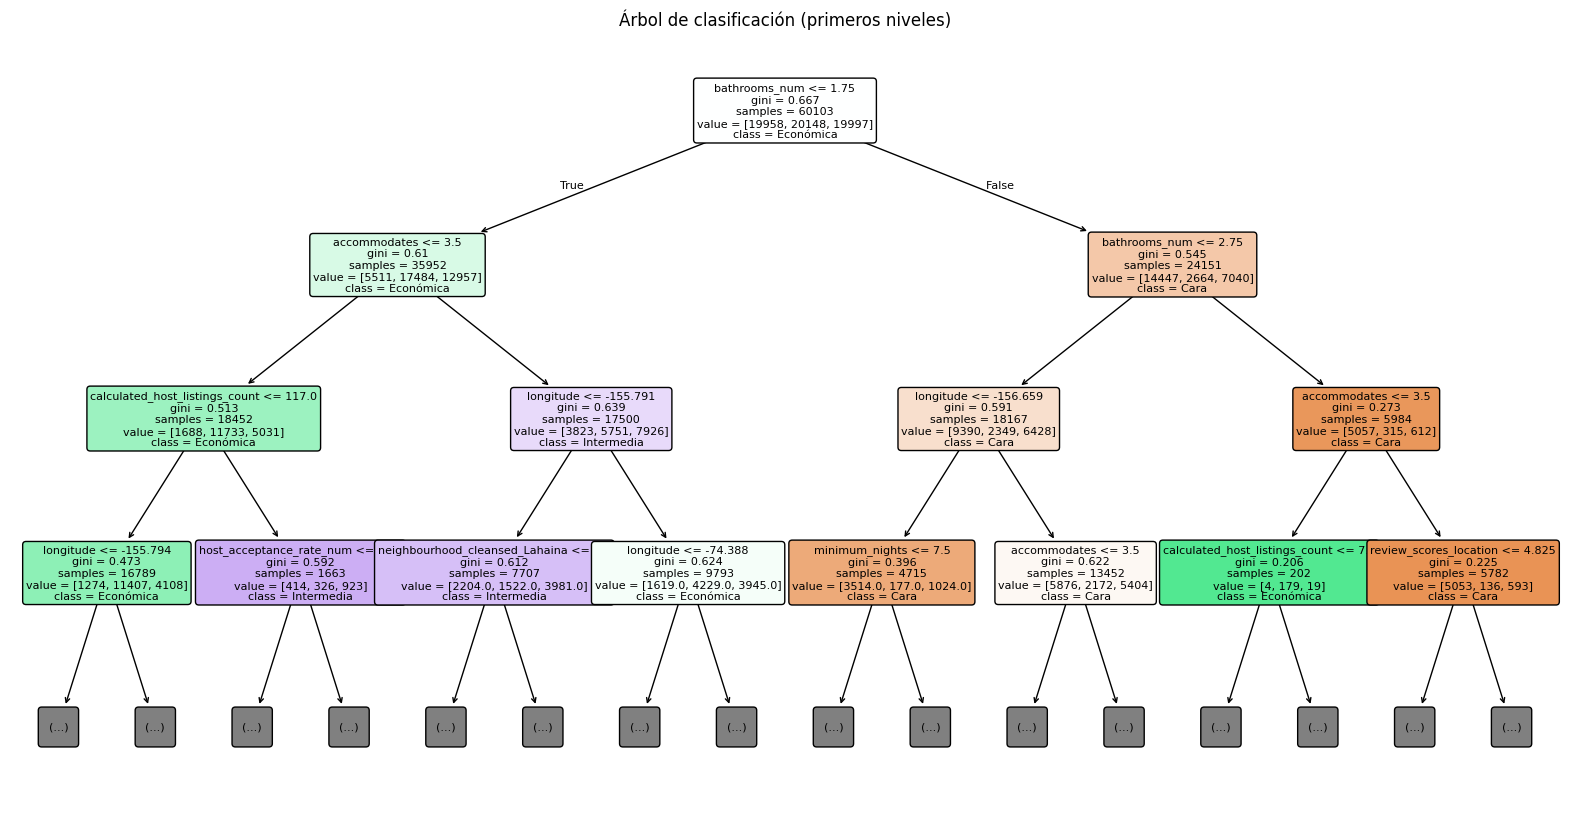

In [36]:
plt.figure(figsize=(20,10))
plot_tree(
    clf_tree.named_steps["model"],
    feature_names=feature_names_clf,
    class_names=clf_tree.named_steps["model"].classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Árbol de clasificación (primeros niveles)")
plt.show()


In [37]:
print(export_text(clf_tree.named_steps["model"], feature_names=feature_names_clf, max_depth=3))


|--- bathrooms_num <= 1.75
|   |--- accommodates <= 3.50
|   |   |--- calculated_host_listings_count <= 117.00
|   |   |   |--- longitude <= -155.79
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- longitude >  -155.79
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- calculated_host_listings_count >  117.00
|   |   |   |--- host_acceptance_rate_num <= 98.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- host_acceptance_rate_num >  98.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- accommodates >  3.50
|   |   |--- longitude <= -155.79
|   |   |   |--- neighbourhood_cleansed_Lahaina <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- neighbourhood_cleansed_Lahaina >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- longitude >  -155.79
|   |   |   |--- longitude <= -74.39
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- longitude >  -74.39
|   |   |   |   |--- truncated

### Lectura del árbol de clasificación

El árbol de clasificación confirma varias intuiciones del análisis exploratorio:

- **número de baños** y **capacidad** aparecen muy arriba en el árbol;
- la **ubicación** (latitud, longitud o ciertos vecindarios) también divide con fuerza;
- variables como `room_type`, `minimum_nights` y algunas señales del host ayudan a refinar las reglas.

La ventaja de este modelo no es solo clasificar, sino ofrecer **reglas interpretables**.  
Por ejemplo, una vivienda tenderá a ir a la clase **Cara** cuando combina mayor tamaño, más baños y ubicaciones premium; en cambio, las **Económicas** se asocian con menos capacidad y perfiles más básicos.

> La evaluación formal del clasificador sobre prueba, la matriz de confusión y la comparación detallada de errores corresponden a los puntos posteriores del laboratorio.


## Conclusiones 

1. El dataset requiere limpieza real: no bastaba con correr modelos directamente sobre la base cruda.
2. El precio por noche está fuertemente influido por variables de tamaño, ubicación, privacidad del alojamiento y señales de demanda.
3. El análisis de grupos mostró que el mercado mezcla propiedades premium, oferta estándar y alojamientos de alta rotación.
4. La selección de variables también importa en árboles: no solo la profundidad, sino **qué señales se dejan entrar**.
5. Entre los árboles evaluados, el mejor resultado aparece cuando se combinan reglas de tamaño, ubicación, reputación y demanda con complejidad controlada.
6. La regresión lineal sirve como baseline interpretable, pero queda limitada frente a la naturaleza no lineal del problema.
7. La nueva variable categórica basada en terciles (`Económica`, `Intermedia`, `Cara`) queda bien fundamentada en la distribución observada del precio.
8. El árbol de clasificación produce reglas coherentes con el análisis exploratorio y deja listo el terreno para la evaluación formal de los siguientes incisos.

Con esto queda cubierto el avance solicitado hasta el **inciso 10**.
